![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/05/logo-upv-horizontal.png)
![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/06/logos-perte-chip-1024x119.png)


# Laboratory 2.0. Coupler Design

## 0. Imports 

### 0.1. General libraries

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import tidy3d as td
import gplugins.tidy3d as gt

nm = 1e-3
wavelength = np.linspace(1500, 1600) * nm
f = td.C_0 / wavelength


### 0.2. Functions by us

In [2]:
from upvfab_design_tools import MMI_EME, DC_EME

In [3]:
nitride_complex = td.material_library["Si3N4"]["Luke2015PMLStable"].eps_model(f)
nitride_index, nitride_k = td.Medium.eps_complex_to_nk(nitride_complex)
box_complex = td.material_library["SiO2"]["Horiba"].eps_model(f)
box_index, box_k = td.Medium.eps_complex_to_nk(box_complex)

## LO.1. Directional coupler length and coupling coefficient

The total power transferred to the output is modeled using the coupling coefficient (K). This coefficient depends on the relationship between the physical length of the coupling region and the beating length:

<img src="k.png" alt="Coupling Coefficient Equation" width="400">

Simulate a directional coupler that implements two deep waveguide cores of 1.2 microns width and with a gap of 600 nm between them. 
- Plot the transfer function: K vs L/Lpi
- Comment the results: distance needed for a complete energy transfer between waveguides, distance needed for splitting power in half.. 

c:\Users\david\Desktop\PIC-CHERTE\DISEÑO\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
c:\Users\david\Desktop\PIC-CHERTE\DISEÑO\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


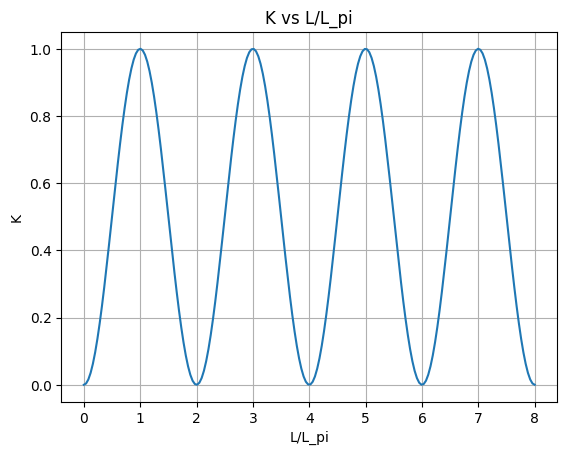

In [4]:
m = DC_EME() # Here you instantiate a Directional Coupler to be simulated with the Eigen-mode expansion (EME) algorithm.
m.DC_wg_gap = 0.6 # Gap between waveguides
m.DC_wg_width = 1.2 # Width of the waveguides core
m.DC_N_waveguides = 2

# 1) Compute de DC modes - Only execute whenever a geometrical parameter is changed. Takes time to find the modes. 
m.find_all_modes()

L_pi=m.get_L_pi()

L=np.linspace(0,8*L_pi,200)
K=np.sin(np.pi/2*(L/L_pi))**2

plt.figure()
plt.plot(L/L_pi, K)
plt.xlabel("L/L_pi")
plt.ylabel("K")
plt.title("K vs L/L_pi")
plt.grid(True)
plt.show()

## LO.2. 2x2 Directional Coupler

Here, you will use some functions provided by us (check **0. Imports** for more details) to simulate the propagation in a 2x2 directional coupler. Please read all the comments in the following code carefully and **make changes only to the lines marked with the #Student tag**

In [ ]:
L_pi_values = []
gap_values = np.arange(0.6, 1.6 + 0.001, 0.1)

for i in gap_values:
# Simulation flow for Directional Couplers
# Define your geometrical parameters here
    wg_gap = i # Student. Gap between waveguides
    wg_width = 1.2 # Student. Core waveguides width

    d = wg_width + wg_gap
    wg_N = 2

    m = DC_EME() # Here you instantiate a Directional Coupler to be simulated with the Eigen-mode expansion (EME) algorithm.
    m.MMI_num_modes = 12 # Number of modes to be calculated. Here, the higher, the better since we are going to calculate
                    # the propagation based on the mode decomposition. 
    m.DC_wg_gap = wg_gap # Gap between waveguides
    m.DC_wg_width = wg_width # Width of the waveguides core
    m.DC_N_waveguides = wg_N

    # 1) Compute de DC modes - Only execute whenever a geometrical parameter is changed. Takes time to find the modes. 
    m.find_all_modes()

    # 2) Get the L_pi 
    L_pi = m.get_L_pi()
    L_pi_values.append(L_pi)
# Summary table
print("\n===== Sweep Results =====")
print(" Gap (µm)    L_pi (µm)")
for g, L in zip(gap_values, L_pi_values):
    print(f"  {g:5.2f}      {L:8.3f}")

c:\Users\david\Desktop\PIC-CHERTE\DISEÑO\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
c:\Users\david\Desktop\PIC-CHERTE\DISEÑO\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
c:\Users\david\Desktop\PIC-CHERTE\DISEÑO\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
c:\Users\david\Desktop\PIC-CHERTE\DISEÑO\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
c:\Users\david\Desktop\PIC-C

c:\Users\david\Desktop\PIC-CHERTE\DISEÑO\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
c:\Users\david\Desktop\PIC-CHERTE\DISEÑO\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/1002 [00:00<?, ?it/s]

------- Pameters -------
MMI length 50.1099
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.8983
Total OUT power: 0.8860
Excess loss [dB] =  0.5256
------------------------
Power over OUTs:  ['0.0015', '0.8845']
Ratio over OUTs ['0.0017', '0.9983']


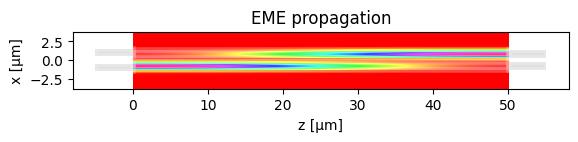

In [7]:
wg_gap = .4 # Student. Gap between waveguides
wg_width = 1.2 # Student. Core waveguides width

d = wg_width + wg_gap
wg_N = 2

m = DC_EME() # Here you instantiate a Directional Coupler to be simulated with the Eigen-mode expansion (EME) algorithm.
m.MMI_num_modes = 12 # Number of modes to be calculated. Here, the higher, the better since we are going to calculate
                    # the propagation based on the mode decomposition. 
m.DC_wg_gap = wg_gap # Gap between waveguides
m.DC_wg_width = wg_width # Width of the waveguides core
m.DC_N_waveguides = wg_N

# 1) Compute de DC modes - Only execute whenever a geometrical parameter is changed. Takes time to find the modes. 
m.find_all_modes()

# 2) Get the L_pi 
L_pi = m.get_L_pi()
# IMPORTANT!!! 
# # If you DON'T change any geometrical parameter
# (waveguide widths or gap) you can skip last cell. 
# YOU CAN RUN the lines below as many times as you wish
# (SAVES TIME)

# 3) Configure DC
# DC I/O number
m.n_IN = 2
m.n_OUT = 2

m.L_MMI = L_pi # Since we use the same library for propagation simulations of MMI and DC 
                    # some variables might be identified as "MMI". Sorry about that (: 
                    # Might change in the future 

# 4) Run propagation - get power transfer and plot propagation
m.propagation()

Text(0.5, 1.0, 'Losses dependence with gaps')

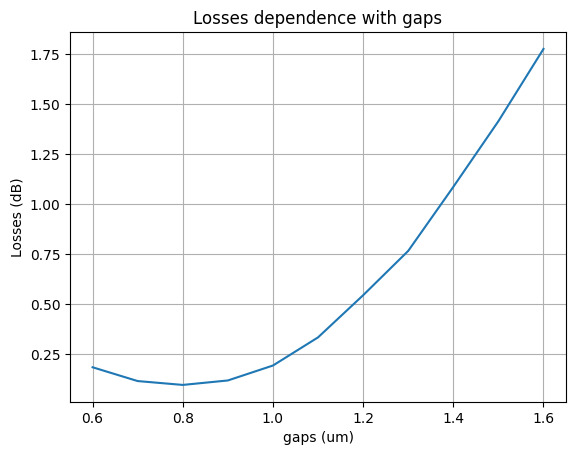

In [8]:
gaps = np.array([0.6,0.7,0.8,.9,1,1.1,1.2,1.3,1.4,1.5,1.6])
losses = np.array([0.1851,0.1161,0.0968,0.1191,0.1938,0.3345,0.5452,0.7669,1.0870,1.4155,1.7769])
ratio = np.array([0.9987,0.9989,0.9990,0.9992,0.9994,0.9995,0.9996,0.9997,0.9997,0.9997,0.9999])

plt.plot(gaps,losses)
plt.grid()
plt.xlabel('gaps (um)')
plt.ylabel('Losses (dB)')
plt.title('Losses dependence with gaps')

Text(0.5, 1.0, 'Ratio dependence with gaps')

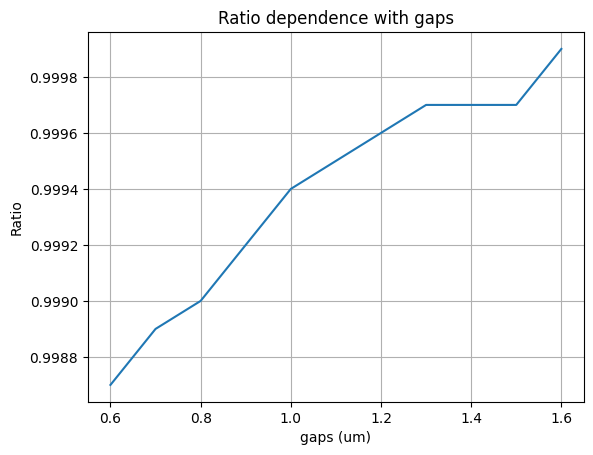

In [9]:
plt.plot(gaps,ratio)
plt.grid()
plt.xlabel('gaps (um)')
plt.ylabel('Ratio')
plt.title('Ratio dependence with gaps')

Si L=L_pi, a una de las salidas no llega nada y toda la potencia llega al otro puerto. Si L=L_pi/2 la potencia idealmente se divide 50/50 en ambos puertos.

## LO.3. Parallel uncoupled waveguides

In [10]:
# HINT. Calculate manually the L_pi you may need to achieve K=0.1
# Then you can sweep the gap and calculate the L_pi until reaching 
# the desired value. 
wg_width = 1 # Student. Core waveguides width
L = 10000
Lpi = []

gaps = np.arange(3, 4 + 0.1, 0.1)  # Sweep
K = [] 

for wg_gap in gaps:

    m = DC_EME()
    m.MMI_num_modes = 12
    m.DC_wg_gap = wg_gap
    m.DC_wg_width = wg_width
    m.DC_N_waveguides = wg_N

    # 1) Calcular modos
    m.find_all_modes()

    # 2) Obtener L_pi
    L_pi = m.get_L_pi()
    Lpi.append(L_pi)  # <-- Guardamos L_pi en el array

    # 3) Calcular K
    k_val = np.sin(np.pi/2 * (L / L_pi))**2
    K.append(k_val)

# Convertimos a arrays de numpy
K = np.array(K)
Lpi = np.array(Lpi)

print("Gaps:", gaps)
print("Lpi:", Lpi)
print("K:", K)

c:\Users\david\Desktop\PIC-CHERTE\DISEÑO\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
c:\Users\david\Desktop\PIC-CHERTE\DISEÑO\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
c:\Users\david\Desktop\PIC-CHERTE\DISEÑO\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
c:\Users\david\Desktop\PIC-CHERTE\DISEÑO\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
c:\Users\david\Desktop\PIC-C

Gaps: [3.  3.1 3.2 3.3 3.4 3.5 3.6 3.7 3.8 3.9 4. ]
Lpi: [  39758.25318933  -51693.67046437  -67159.1580228   -87180.23676486
  110094.9173917  -145655.90525357  183913.32453355 -243750.58819893
  319326.87201157 -414788.06832902 -533249.74582318]
K: [0.14813905 0.08952757 0.05371497 0.03211433 0.02021884 0.01158509
 0.00727708 0.00414713 0.00241779 0.00143344 0.00086747]


c:\Users\david\Desktop\PIC-CHERTE\DISEÑO\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


Text(0.5, 1.0, 'K vs Gap')

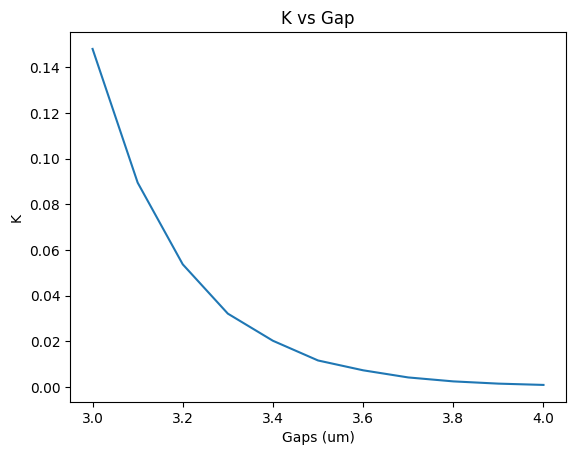

In [11]:
plt.plot(gaps,K)
plt.xlabel('Gaps (um)')
plt.ylabel('K')
plt.title('K vs Gap')

## LO.4. 2x2 Multimode Interference Coupler

### LO.4.1 Propagation Simulation

For the multimode interference (MMI) couplers we must rely on the design tables shown on the theoretical session: 

<img src="mmi.png" alt="Design tables for MMI couplers" width="600">

Here, you will use some functions provided by us (check **0. Imports** for more details) to simulate the propagation in a 2x2 directional coupler. Please read all the comments in the following code carefully and **make changes only to the lines marked with the #Student tag**

In [12]:
# Simulation flow for MMI Couplers
# Define your geometrical parameters here
mmi_Width = 6.6 # Student. Body width

m = MMI_EME() # Here you instantiate a MMI to be simulated with the Eigen-mode expansion (EME) algorithm.
m.MMI_width = mmi_Width
m.MMI_num_modes = 20 # Number of modes to be calculated. Here, the higher, the better since we are going to calculate
                    # the propagation based on the mode decomposition. 

# 1) Compute de MMI body modes - Only execute whenever a geometrical parameter is changed. Takes time to find the modes. 
m.find_all_modes()

# 2) Get the L_pi 
L_pi = m.get_L_pi()
print("L_pi = ", L_pi, " µm")

c:\Users\david\Desktop\PIC-CHERTE\DISEÑO\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  69.03598607256414  µm


c:\Users\david\Desktop\PIC-CHERTE\DISEÑO\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/690 [00:00<?, ?it/s]

------- Pameters -------
MMI length 34.5180
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9604
Total OUT power: 0.9075
Excess loss [dB] =  0.4217
------------------------
Power over OUTs:  ['0.4675', '0.4399']
Ratio over OUTs ['0.5152', '0.4848']


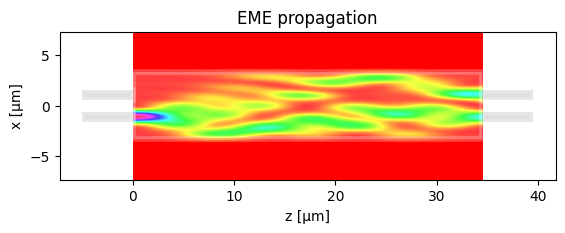

In [13]:
# IMPORTANT!!! 
# # If you DON'T change neither the MMI width 
# nor input/output waveguide widths
# YOU CAN RUN the lines below as many times as you wish
# (SAVES TIME)

# 3) Configure MMI
# # MMI I/O number (check class slides for type of MMI)
m.n_IN =  2 # STUDENT
m.n_OUT = 2 # STUDENT

# MMI I/O waveguide positions (check class slides for type of MMI)
m.IN_WVG_positions = mmi_Width*np.array([-1/6,1/6]) # STUDENT
m.OUT_WVG_positions = mmi_Width*np.array([-1/6,1/6]) # STUDENT

# MMI length (check class slides for type of MMI)
m.L_MMI = L_pi/2 # STUDENT

# Run propagation
m.propagation()

### LO.4.2. 2x2 Multimode Interference Coupler - Optimization

  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/680 [00:00<?, ?it/s]

------- Pameters -------
MMI length 34.5180
MMI length increment -0.5000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9524
Total OUT power: 0.9032
Excess loss [dB] =  0.4423
------------------------
Power over OUTs:  ['0.4560', '0.4472']
Ratio over OUTs ['0.5049', '0.4951']


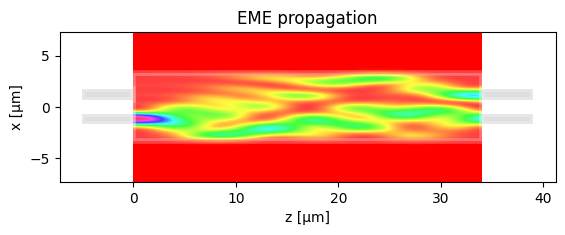

In [14]:
dy = 0.1
# MMI I/O waveguide positions (check class slides for type of MMI)
m.IN_WVG_positions = mmi_Width*np.array([-1/6,1/6]) + np.array([-dy,dy]) # STUDENT
m.OUT_WVG_positions = mmi_Width*np.array([-1/6,1/6]) + np.array([-dy,dy]) # STUDENT

# MMI length (check class slides for type of MMI)
m.dL_MMI = -0.5 # STUDENT

# Run propagation
m.propagation()

### LO.4.3 2x2 Multimode Interference Coupler – Optimization (II)

c:\Users\david\Desktop\PIC-CHERTE\DISEÑO\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
c:\Users\david\Desktop\PIC-CHERTE\DISEÑO\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/680 [00:00<?, ?it/s]

------- Pameters -------
MMI length 34.5180
MMI length increment -0.5000
IO wg width 1.0000
IO wg width increment 1.3000
------------------------
Total power IN coupled 0.9995
Total OUT power: 0.9963
Excess loss [dB] =  0.0159
------------------------
Power over OUTs:  ['0.5099', '0.4864']
Ratio over OUTs ['0.5118', '0.4882']


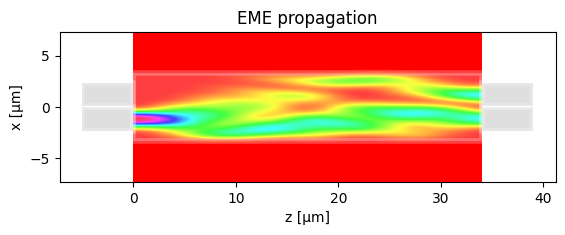

In [15]:
# Design flow for MMI

m = MMI_EME()
m.MMI_width = 6.6   # MMI width
m.wg_width_dw = 1.3 # STUDENT

# 1) Compute de MMI modes
m.find_all_modes()

# 2) Get the L_pi
L_pi = m.get_L_pi()

# 3) Configure MMI
# # MMI I/O number (check class slides for type of MMI)
m.n_IN = 2 # STUDENT
m.n_OUT = 2 # STUDENT

dy = 0.1
# MMI I/O waveguide positions (check class slides for type of MMI)
m.IN_WVG_positions = mmi_Width*np.array([-1/6,1/6]) + np.array([-dy,dy]) # STUDENT
m.OUT_WVG_positions = mmi_Width*np.array([-1/6,1/6]) + np.array([-dy,dy]) # STUDENT

# MMI length (check class slides for type of MMI)
m.L_MMI = L_pi/2  # STUDENT
m.dL_MMI = -.5 # STUDENT

# Run propagation
m.propagation()

## LO.5. 1x4 1x4 Multimode Interference Coupler 

Repeat the design procedure explained for the 2x2 Coupler to design a 1x4 MMI Coupler. Consider: 
- Select a suitable MMI body width, taking into account that you now must allocate 4 waveguides at the output. 
- Minimize the losses and output imbalance for the MMI coupler. 

c:\Users\david\Desktop\PIC-CHERTE\DISEÑO\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
c:\Users\david\Desktop\PIC-CHERTE\DISEÑO\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/13 [00:00<?, ?it/s]

  0%|          | 0/822 [00:00<?, ?it/s]

------- Pameters -------
MMI length 41.0886
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9612
Total OUT power: 0.8578
Excess loss [dB] =  0.6661
------------------------
Power over OUTs:  ['0.2144', '0.2146', '0.2146', '0.2143']
Ratio over OUTs ['0.2499', '0.2501', '0.2501', '0.2498']


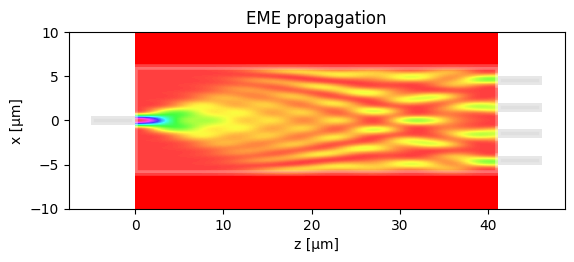

In [20]:
# Simulation flow for MMI Couplers
# Define your geometrical parameters here
mmi_Width = 12 # Student. Body width

m = MMI_EME() # Here you instantiate a MMI to be simulated with the Eigen-mode expansion (EME) algorithm.
m.MMI_width = mmi_Width
m.MMI_num_modes = 40 # Number of modes to be calculated. Here, the higher, the better since we are going to calculate
                    # the propagation based on the mode decomposition. 

# 1) Compute de MMI body modes - Only execute whenever a geometrical parameter is changed. Takes time to find the modes. 
m.find_all_modes()

# 2) Get the L_pi 
L_pi = m.get_L_pi()

# 3) Configure MMI
# # MMI I/O number (check class slides for type of MMI)
m.n_IN =  1 # STUDENT
m.n_OUT = 4 # STUDENT

# MMI I/O waveguide positions (check class slides for type of MMI)
m.IN_WVG_positions = np.array([0]) # STUDENT
m.OUT_WVG_positions = mmi_Width*np.array([-3/8, -1/8, 1/8, 3/8]) # STUDENT

# MMI length (check class slides for type of MMI)
m.L_MMI = 3*L_pi/16 # STUDENT

# Run propagation
m.propagation()

  0%|          | 0/13 [00:00<?, ?it/s]

  0%|          | 0/798 [00:00<?, ?it/s]

------- Pameters -------
MMI length 41.0886
MMI length increment -1.2000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9599
Total OUT power: 0.9012
Excess loss [dB] =  0.4520
------------------------
Power over OUTs:  ['0.2351', '0.2261', '0.2143', '0.2257']
Ratio over OUTs ['0.2609', '0.2509', '0.2378', '0.2505']


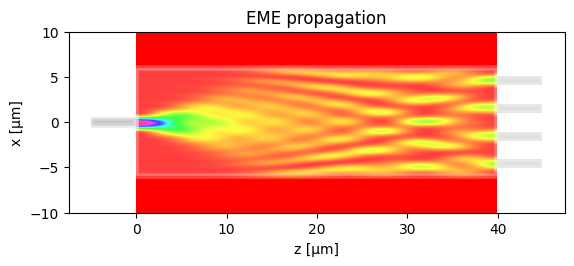

In [46]:
dy = 0.1
# MMI I/O waveguide positions (check class slides for type of MMI)
m.IN_WVG_positions = np.array([0]) + np.array([-dy,dy]) # STUDENT
m.OUT_WVG_positions = mmi_Width*np.array([-3/8, -1/8, 1/8, 3/8]) + np.array([-dy, -dy/2 ,dy/2, dy]) # STUDENT

# MMI length (check class slides for type of MMI)
m.dL_MMI = -1.2 # STUDENT

# Run propagation
m.propagation()

c:\Users\david\Desktop\PIC-CHERTE\DISEÑO\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
c:\Users\david\Desktop\PIC-CHERTE\DISEÑO\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/12 [00:00<?, ?it/s]

  0%|          | 0/798 [00:00<?, ?it/s]

------- Pameters -------
MMI length 41.0886
MMI length increment -1.2000
IO wg width 1.0000
IO wg width increment 2.0000
------------------------
Total power IN coupled 0.9982
Total OUT power: 0.9997
Excess loss [dB] =  0.0015
------------------------
Power over OUTs:  ['0.2453', '0.2688', '0.2601', '0.2254']
Ratio over OUTs ['0.2454', '0.2689', '0.2602', '0.2255']


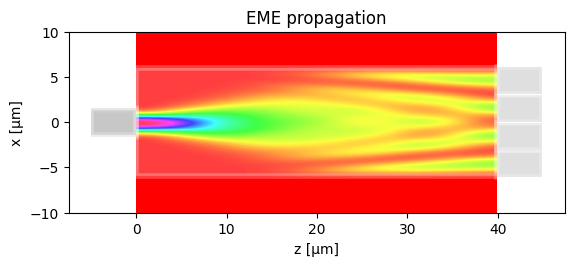

In [52]:
# Design flow for MMI
m = MMI_EME()
m.MMI_width = 12   # MMI width
m.wg_width_dw = 2 # STUDENT

# 1) Compute de MMI modes
m.find_all_modes()

# 2) Get the L_pi
L_pi = m.get_L_pi()

# 3) Configure MMI
# # MMI I/O number (check class slides for type of MMI)
m.n_IN = 1 # STUDENT
m.n_OUT = 4 # STUDENT

dy = 0.1
# MMI I/O waveguide positions (check class slides for type of MMI)
m.IN_WVG_positions = np.array([0]) + np.array([-dy,dy]) # STUDENT
m.OUT_WVG_positions = mmi_Width*np.array([-3/8, -1/8, 1/8, 3/8]) + np.array([-dy, -dy/2 ,dy/2, dy]) # STUDENT

# MMI length (check class slides for type of MMI)
m.L_MMI = 3*L_pi/16  # STUDENT
m.dL_MMI = -1.2 # STUDENT

# Run propagation
m.propagation()

## Extra - Exercises

### E1. Directional coupler wavelength dependence

#### Deep case

In [5]:
gap_to_simulate = 600 * nm # STUDENT. You can manually change the gap
                            # or you can sweep the parameter using a Python for loop. 
wavelength = np.linspace(1.5,1.7,80)

Lpi_TE = []
Lpi_TM= []

for wl in wavelength:

    dc = gt.modes.WaveguideCoupler(
        wavelength=wl,
        core_width=(1.0, 1.0),
        gap=gap_to_simulate,
        slab_thickness=0 * nm,
        core_material='sin',
        clad_material='sio2',
        core_thickness=300 * nm,
        num_modes=4,
        cache_path='.cache/',
        precision='double',
        max_grid_scaling=1.5,
        grid_resolution=20
    )

    neff = dc.n_eff
    frac = dc.fraction_te

    if frac[0] and frac[1]>0.9:
        print('TE')

2026-03-08 13:58:33.132 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\WaveguideCoupler_fc2c62c75e0d5f6e.npz.
TE
2026-03-08 13:58:33.148 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\WaveguideCoupler_533857b17e3803dd.npz.
TE
2026-03-08 13:58:33.160 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\WaveguideCoupler_56d28df39ab38b66.npz.
TE
2026-03-08 13:58:33.176 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\WaveguideCoupler_41510a84fc8c6d72.npz.
TE
2026-03-08 13:58:33.195 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\WaveguideCoupler_90e8b7d2eb2f8bc0.npz.
TE
2026-03-08 13:58:33.210 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\WaveguideCoupler_f25325cc7d419cd5.npz.
TE
2026-03-08 13:58:33.225 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\WaveguideCoupler_3994859eda5e468f.npz.
TE
2026-03-08 13:58:33.238 | INFO     | gplugins.tidy3d.mo

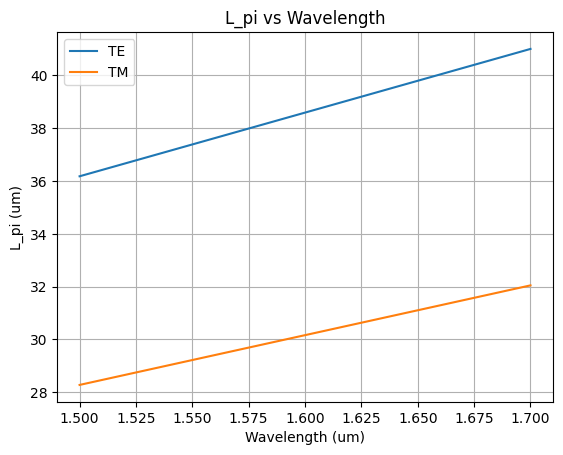

In [6]:
for wl in wavelength:
    Lpi_TE.append(wl/(2*(neff[0].real-neff[1].real)))
    Lpi_TM.append(wl/(2*(neff[2].real-neff[3].real)))

# STUDENT. Plot goes here
# Convert to arrays
Lpi_TE = np.array(Lpi_TE)
Lpi_TM = np.array(Lpi_TM)

# Plot
plt.figure()
plt.plot(wavelength, Lpi_TE, label='TE')
plt.plot(wavelength, Lpi_TM, label='TM')

plt.xlabel('Wavelength (um)')
plt.ylabel('L_pi (um)')
plt.title('L_pi vs Wavelength')
plt.legend()
plt.grid()

plt.show()

#### Shallow case

2026-03-08 14:02:32.184 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\WaveguideCoupler_29275665d8177d38.npz.
2026-03-08 14:02:32.196 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\WaveguideCoupler_dbc0af4e67739848.npz.
2026-03-08 14:02:32.205 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\WaveguideCoupler_45c22966eeb98392.npz.
2026-03-08 14:02:32.218 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\WaveguideCoupler_7affc0dab894b8a5.npz.
2026-03-08 14:02:32.229 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\WaveguideCoupler_80752ab22ec2b98a.npz.
2026-03-08 14:02:32.241 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\WaveguideCoupler_79818c67defc66df.npz.
2026-03-08 14:02:32.251 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\WaveguideCoupler_19a1da250e1af5a5.npz.
2026-03-08 14:02:32.261 | INFO     | gplugins.tidy3d.modes:_data:266 - load 

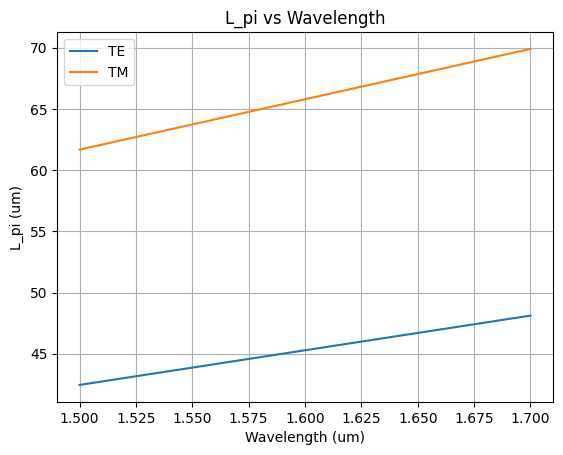

[np.complex128(1.6248672556218713+0.0001033784949909237j), np.complex128(1.6072004255639063+0.00010096611813360196j), np.complex128(1.5266055924361064+0.0001562361663100802j), np.complex128(1.6507417840857468+9.066382785554782e-05j), np.complex128(1.633018086437903+8.854669917204875e-05j), np.complex128(1.5638557060762281+0.0001346369032626568j), np.complex128(1.5571147681277622+0.00013699465071073512j), np.complex128(1.6358010401685013+9.780843571972644e-05j), np.complex128(1.6178635604573437+9.564449978176268e-05j), np.complex128(1.5468183630487848+0.00014489133661801018j), np.complex128(1.5395407404166912+0.00014797227029845851j), np.complex128(1.6498780090021452+9.078417391776722e-05j), np.complex128(1.631954235426326+8.872451240974696e-05j), np.complex128(1.5632156023909356+0.00013458188001014854j), np.complex128(1.5564881155525696+0.00013679049412576726j), np.complex128(1.6351824925663252+9.760549839104574e-05j), np.complex128(1.6171514302669678+9.540254965929985e-05j), np.comple

In [8]:
gap_to_simulate = 600 * nm # STUDENT. You can manually change the gap
                            # or you can sweep the parameter using a Python for loop. 
wavelength = np.linspace(1.5,1.7,80)

Lpi_TE = []
Lpi_TM= []

TE = []
TM = []

for wl in wavelength:

    dc = gt.modes.WaveguideCoupler(
        wavelength=wl,
        core_width=(1.0, 1.0),
        gap=gap_to_simulate,
        slab_thickness=150 * nm,
        core_material='sin',
        clad_material='sio2',
        core_thickness=300 * nm,
        num_modes=6,
        cache_path='.cache/',
        precision='double',
        max_grid_scaling=1.5,
        grid_resolution=20
    )

    neff = dc.n_eff
    TE_frac = dc.fraction_te
    # Recorrer cada modo
    for idx, frac in enumerate(TE_frac):
        if frac > 0.9:
            TE.append(neff[idx])
        else:
            TM.append(neff[idx])
           
    Lpi_TE.append(wl/(2*(TE[0].real-TE[1].real)))
    Lpi_TM.append(wl/(2*(TM[0].real-TM[1].real)))

# STUDENT. Plot goes here
# Convert to arrays
Lpi_TE = np.array(Lpi_TE)
Lpi_TM = np.array(Lpi_TM)

# Plot
plt.figure()
plt.plot(wavelength, Lpi_TE, label='TE')
plt.plot(wavelength, Lpi_TM, label='TM')

plt.xlabel('Wavelength (um)')
plt.ylabel('L_pi (um)')
plt.title('L_pi vs Wavelength')
plt.legend()
plt.grid()

plt.show()
print(TE)

### E2. Directional coupler gap dependence. CORREGIR

#### Deep case

c:\Users\david\Desktop\PIC-CHERTE\DISEÑO\pic-upv-lab2\.venv\Lib\site-packages\tidy3d\components\mode\derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
c:\Users\david\Desktop\PIC-CHERTE\DISEÑO\pic-upv-lab2\.venv\Lib\site-packages\tidy3d\components\mode\derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
c:\Users\david\Desktop\PIC-CHERTE\DISEÑO\pic-upv-lab2\.ve

2026-03-09 15:00:20.274 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache\WaveguideCoupler_11c4f9b94f3a3ed9.npz.


c:\Users\david\Desktop\PIC-CHERTE\DISEÑO\pic-upv-lab2\.venv\Lib\site-packages\tidy3d\components\mode\derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
c:\Users\david\Desktop\PIC-CHERTE\DISEÑO\pic-upv-lab2\.venv\Lib\site-packages\tidy3d\components\mode\derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
c:\Users\david\Desktop\PIC-CHERTE\DISEÑO\pic-upv-lab2\.ve

2026-03-09 15:00:22.768 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache\WaveguideCoupler_050f074001e8f60a.npz.


c:\Users\david\Desktop\PIC-CHERTE\DISEÑO\pic-upv-lab2\.venv\Lib\site-packages\tidy3d\components\mode\derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
c:\Users\david\Desktop\PIC-CHERTE\DISEÑO\pic-upv-lab2\.venv\Lib\site-packages\tidy3d\components\mode\derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
c:\Users\david\Desktop\PIC-CHERTE\DISEÑO\pic-upv-lab2\.ve

...

2026-03-09 15:00:42.823 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache\WaveguideCoupler_3a587fa064f1d9c5.npz.


c:\Users\david\Desktop\PIC-CHERTE\DISEÑO\pic-upv-lab2\.venv\Lib\site-packages\tidy3d\components\mode\derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
c:\Users\david\Desktop\PIC-CHERTE\DISEÑO\pic-upv-lab2\.venv\Lib\site-packages\tidy3d\components\mode\derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
c:\Users\david\Desktop\PIC-CHERTE\DISEÑO\pic-upv-lab2\.ve

2026-03-09 15:00:46.139 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache\WaveguideCoupler_f98a059628c798cd.npz.


c:\Users\david\Desktop\PIC-CHERTE\DISEÑO\pic-upv-lab2\.venv\Lib\site-packages\tidy3d\components\mode\derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
c:\Users\david\Desktop\PIC-CHERTE\DISEÑO\pic-upv-lab2\.venv\Lib\site-packages\tidy3d\components\mode\derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
c:\Users\david\Desktop\PIC-CHERTE\DISEÑO\pic-upv-lab2\.ve

2026-03-09 15:00:49.711 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache\WaveguideCoupler_0fa2df291a8afef4.npz.


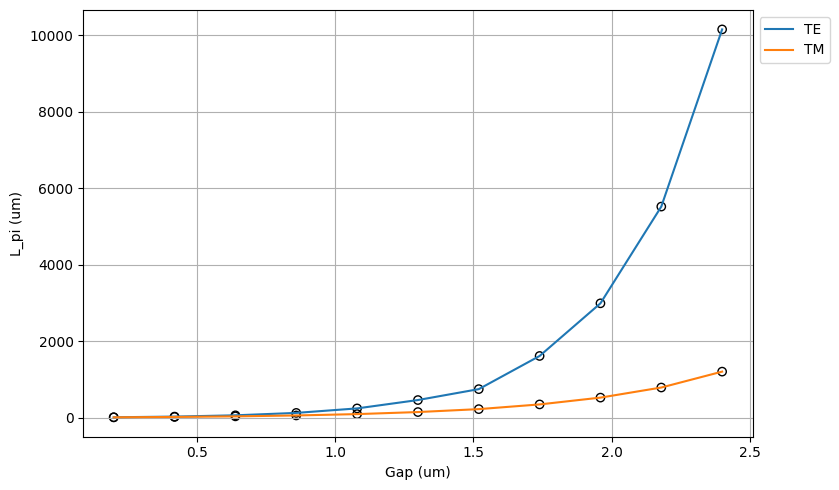

In [50]:
wavelength = 1.55
gap = np.linspace(0.2,2.4,11)

Lpi_TE = []
Lpi_TM = []

for g in gap:

    dc = gt.modes.WaveguideCoupler(
        wavelength=wavelength,
        core_width=(1.0,1.0),
        gap=g,
        slab_thickness=0*nm,
        core_material='sin',
        clad_material='sio2',
        core_thickness=300*nm,
        num_modes=4,
        cache_path='.cache/',
        precision='double',
        max_grid_scaling=1.5,
        grid_resolution=30
    )

    neff = dc.n_eff
    TE_frac = dc.fraction_te

    TE_modes = []
    TM_modes = []

    for idx, frac in enumerate(TE_frac):
        if frac > 0.8:
            TE_modes.append(neff[idx].real)
        elif frac < 0.2:
            TM_modes.append(neff[idx].real)

    TE_modes = sorted(TE_modes, reverse=True)
    TM_modes = sorted(TM_modes, reverse=True)

    if len(TE_modes) >= 2:
        Lpi_TE.append(wavelength/(2*(TE_modes[0]-TE_modes[1])))
    else:
        Lpi_TE.append(np.nan)

    if len(TM_modes) >= 2:
        Lpi_TM.append(wavelength/(2*(TM_modes[0]-TM_modes[1])))
    else:
        Lpi_TM.append(np.nan)
        
plt.figure(figsize=(10, 5))
plt.scatter(gap, Lpi_TE,edgecolors='k',facecolors='none',label = '__nolegend__')
plt.plot(gap, Lpi_TE,label='TE')
plt.scatter(gap, Lpi_TM,edgecolors='k',facecolors='none',label = '__nolegend__')
plt.plot(gap, Lpi_TM,label='TM')
plt.xlabel("Gap (um)")
plt.ylabel("L_pi (um)")
plt.grid()
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout(rect=[0, 0, 0.85, 1])

#### Shallow case

c:\Users\david\Desktop\PIC-CHERTE\DISEÑO\pic-upv-lab2\.venv\Lib\site-packages\tidy3d\components\mode\derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
c:\Users\david\Desktop\PIC-CHERTE\DISEÑO\pic-upv-lab2\.venv\Lib\site-packages\tidy3d\components\mode\derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
c:\Users\david\Desktop\PIC-CHERTE\DISEÑO\pic-upv-lab2\.ve

15:30:44 Hora estándar romance WARNING: Mode field at frequency index 0, mode   
                               index 3 does not decay at the plane boundaries.  

                               WARNING: Mode field at frequency index 0, mode   
                               index 4 does not decay at the plane boundaries.  

                               WARNING: Mode field at frequency index 0, mode   
                               index 8 does not decay at the plane boundaries.  

2026-03-09 15:30:44.516 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache\WaveguideCoupler_59fa2de538147e77.npz.


...

2026-03-09 15:36:03.922 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache\WaveguideCoupler_bf989b9f85bdc457.npz.


c:\Users\david\Desktop\PIC-CHERTE\DISEÑO\pic-upv-lab2\.venv\Lib\site-packages\tidy3d\components\mode\derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
c:\Users\david\Desktop\PIC-CHERTE\DISEÑO\pic-upv-lab2\.venv\Lib\site-packages\tidy3d\components\mode\derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
c:\Users\david\Desktop\PIC-CHERTE\DISEÑO\pic-upv-lab2\.ve

2026-03-09 15:36:57.646 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache\WaveguideCoupler_b4c9d8309089f022.npz.


c:\Users\david\Desktop\PIC-CHERTE\DISEÑO\pic-upv-lab2\.venv\Lib\site-packages\tidy3d\components\mode\derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
c:\Users\david\Desktop\PIC-CHERTE\DISEÑO\pic-upv-lab2\.venv\Lib\site-packages\tidy3d\components\mode\derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
c:\Users\david\Desktop\PIC-CHERTE\DISEÑO\pic-upv-lab2\.ve

2026-03-09 15:37:51.452 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache\WaveguideCoupler_5d291986e84edeb9.npz.


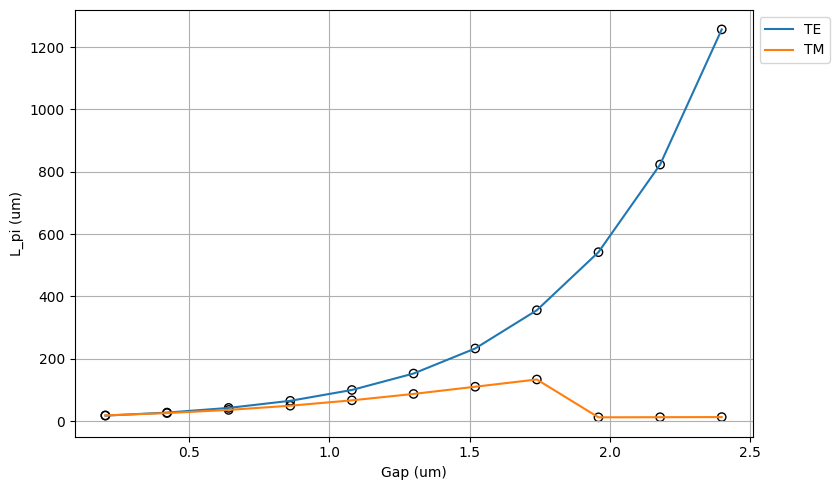

In [59]:
wavelength = 1.55
gap = np.linspace(0.2,2.4,11)

Lpi_TE = []
Lpi_TM = []

for g in gap:

    dc = gt.modes.WaveguideCoupler(
        wavelength=wavelength,
        core_width=(1.0,1.0),
        gap=g,
        slab_thickness=150*nm,
        core_material='sin',
        clad_material='sio2',
        core_thickness=300*nm,
        num_modes=9,
        cache_path='.cache/',
        precision='double',
        max_grid_scaling=1.75,
        grid_resolution=80
    )

    neff = dc.n_eff
    TE_frac = dc.fraction_te

    TE_modes = []
    TM_modes = []

    for idx, frac in enumerate(TE_frac):
        if frac > 0.8:
            TE_modes.append(neff[idx].real)
        elif frac < 0.2:
            TM_modes.append(neff[idx].real)


    if len(TE_modes) >= 2:
        Lpi_TE.append(wavelength/(2*(TE_modes[0]-TE_modes[1])))
    else:
        Lpi_TE.append(np.nan)

    if len(TM_modes) >= 2:
        Lpi_TM.append(wavelength/(2*(TM_modes[0]-TM_modes[1])))
    else:
        Lpi_TM.append(np.nan)
        
plt.figure(figsize=(10, 5))
plt.scatter(gap, Lpi_TE,edgecolors='k',facecolors='none',label = '__nolegend__')
plt.plot(gap, Lpi_TE,label='TE')
plt.scatter(gap, Lpi_TM,edgecolors='k',facecolors='none',label = '__nolegend__')
plt.plot(gap, Lpi_TM,label='TM')
plt.xlabel("Gap (um)")
plt.ylabel("L_pi (um)")
plt.grid()
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout(rect=[0, 0, 0.85, 1])

### E3. MMI coupler wavelength dependence

#### Deep case

2026-03-08 14:34:44.198 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_9a2f1ddbafc80a93.npz.


c:\Users\david\Desktop\PIC-CHERTE\DISEÑO\pic-upv-lab2\.venv\Lib\site-packages\tidy3d\components\mode\derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
c:\Users\david\Desktop\PIC-CHERTE\DISEÑO\pic-upv-lab2\.venv\Lib\site-packages\tidy3d\components\mode\derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
c:\Users\david\Desktop\PIC-CHERTE\DISEÑO\pic-upv-lab2\.ve

14:34:46 Hora estándar romance WARNING: Mode field at frequency index 0, mode   
                               index 14 does not decay at the plane boundaries. 

2026-03-08 14:34:46.908 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache\Waveguide_70551edd4e9537bb.npz.


c:\Users\david\Desktop\PIC-CHERTE\DISEÑO\pic-upv-lab2\.venv\Lib\site-packages\tidy3d\components\mode\derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
c:\Users\david\Desktop\PIC-CHERTE\DISEÑO\pic-upv-lab2\.venv\Lib\site-packages\tidy3d\components\mode\derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
c:\Users\david\Desktop\PIC-CHERTE\DISEÑO\pic-upv-lab2\.ve

...

c:\Users\david\Desktop\PIC-CHERTE\DISEÑO\pic-upv-lab2\.venv\Lib\site-packages\tidy3d\components\mode\derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
c:\Users\david\Desktop\PIC-CHERTE\DISEÑO\pic-upv-lab2\.venv\Lib\site-packages\tidy3d\components\mode\derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
c:\Users\david\Desktop\PIC-CHERTE\DISEÑO\pic-upv-lab2\.ve

14:38:29 Hora estándar romance WARNING: Mode field at frequency index 0, mode   
                               index 12 does not decay at the plane boundaries. 

                               WARNING: Mode field at frequency index 0, mode   
                               index 13 does not decay at the plane boundaries. 

                               WARNING: Mode field at frequency index 0, mode   
                               index 14 does not decay at the plane boundaries. 

2026-03-08 14:38:29.170 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache\Waveguide_651f1900936eeaa4.npz.
2026-03-08 14:38:29.193 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_0b298110b2400b7a.npz.


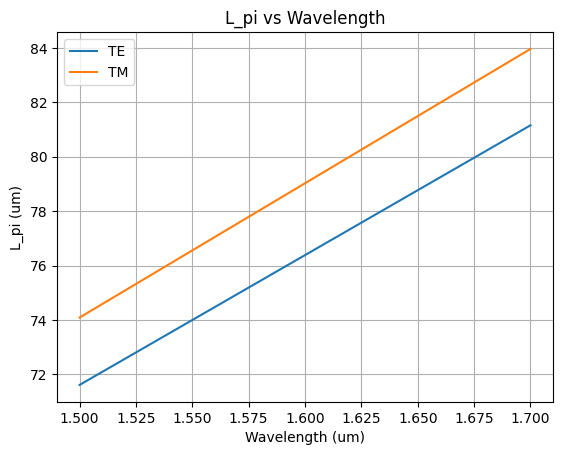

In [ ]:
gap_to_simulate = 600 * nm # STUDENT. You can manually change the gap
                            # or you can sweep the parameter using a Python for loop. 
wavelength = 1.55

mmi_body_w = 6.6

Lpi_TE = []
Lpi_TM= []

TE = []
TM = []

for wl in wavelength:

    dc = gt.modes.WaveguideCoupler(
        wavelength=wavelength,
        core_width=(1.0,1.0),
        gap=g,
        slab_thickness=150*nm,
        core_material='sin',
        clad_material='sio2',
        core_thickness=300*nm,
        num_modes=4,
        cache_path='.cache/',
        precision='double',
        max_grid_scaling=1.5,
        grid_resolution=20
    )

    neff = mmi.n_eff
    TE_frac = mmi.fraction_te
    # Recorrer cada modo
    for idx, frac in enumerate(TE_frac):
        if frac > 0.9:
            TE.append(neff[idx])
        else:
            TM.append(neff[idx])
           
    Lpi_TE.append(wl/(2*(TE[0].real-TE[1].real)))
    Lpi_TM.append(wl/(2*(TM[0].real-TM[1].real)))

# STUDENT. Plot goes here
# Convert to arrays
Lpi_TE = np.array(Lpi_TE)
Lpi_TM = np.array(Lpi_TM)

# Plot
plt.figure()
plt.plot(wavelength, Lpi_TE, label='TE')
plt.plot(wavelength, Lpi_TM, label='TM')

plt.xlabel('Wavelength (um)')
plt.ylabel('L_pi (um)')
plt.title('L_pi vs Wavelength')
plt.legend()
plt.grid()

plt.show()

#### Shallow case

c:\Users\david\Desktop\PIC-CHERTE\DISEÑO\pic-upv-lab2\.venv\Lib\site-packages\tidy3d\components\mode\derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
c:\Users\david\Desktop\PIC-CHERTE\DISEÑO\pic-upv-lab2\.venv\Lib\site-packages\tidy3d\components\mode\derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
c:\Users\david\Desktop\PIC-CHERTE\DISEÑO\pic-upv-lab2\.ve

14:39:35 Hora estándar romance WARNING: Mode field at frequency index 0, mode   
                               index 9 does not decay at the plane boundaries.  

                               WARNING: Mode field at frequency index 0, mode   
                               index 11 does not decay at the plane boundaries. 

                               WARNING: Mode field at frequency index 0, mode   
                               index 12 does not decay at the plane boundaries. 

2026-03-08 14:39:35.093 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache\Waveguide_c26c25376372bde5.npz.


...

14:42:54 Hora estándar romance WARNING: Mode field at frequency index 0, mode   
                               index 8 does not decay at the plane boundaries.  

                               WARNING: Mode field at frequency index 0, mode   
                               index 9 does not decay at the plane boundaries.  

                               WARNING: Mode field at frequency index 0, mode   
                               index 11 does not decay at the plane boundaries. 

                               WARNING: Mode field at frequency index 0, mode   
                               index 13 does not decay at the plane boundaries. 

2026-03-08 14:42:54.730 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache\Waveguide_7a54b34d317d0af0.npz.


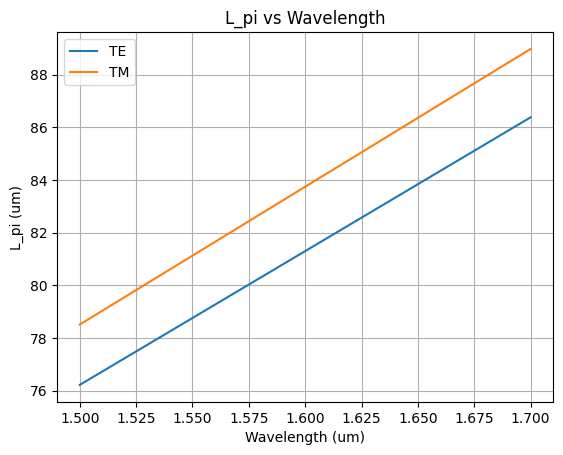

In [31]:
gap_to_simulate = 600 * nm # STUDENT. You can manually change the gap
                            # or you can sweep the parameter using a Python for loop. 
wavelength = np.linspace(1.5,1.7,80)

mmi_body_w = 6.6

Lpi_TE = []
Lpi_TM= []

TE = []
TM = []

for wl in wavelength:

    mmi = gt.modes.Waveguide(
        # Geometrical Parameters
        core_width=mmi_body_w, # MMI Body width
        core_thickness=300 * nm, # MMI Body height 
        slab_thickness=150 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguides.
        # Materials
        core_material='sin', #  Material of the waveguide
        clad_material='sio2', # Surrounding material
        # Modesolver Parameters
        wavelength=wl, # Wavelength to simulate
        num_modes=15, # Targeted number of modes to find - Higher than before! It's a multimode section
        max_grid_scaling=1.5, # Parameters of the grid
        grid_resolution=20, # Parameters of the grid
        cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
        precision='double',
    )


    neff = mmi.n_eff
    TE_frac = mmi.fraction_te
    # Recorrer cada modo
    for idx, frac in enumerate(TE_frac):
        if frac > 0.9:
            TE.append(neff[idx])
        else:
            TM.append(neff[idx])
           
    Lpi_TE.append(wl/(2*(TE[0].real-TE[1].real)))
    Lpi_TM.append(wl/(2*(TM[0].real-TM[1].real)))

# STUDENT. Plot goes here
# Convert to arrays
Lpi_TE = np.array(Lpi_TE)
Lpi_TM = np.array(Lpi_TM)

# Plot
plt.figure()
plt.plot(wavelength, Lpi_TE, label='TE')
plt.plot(wavelength, Lpi_TM, label='TM')

plt.xlabel('Wavelength (um)')
plt.ylabel('L_pi (um)')
plt.title('L_pi vs Wavelength')
plt.legend()
plt.grid()

plt.show()

### E4. MMI coupler body width dependence

#### Deep case

2026-03-09 14:31:00.062 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_750afcc7e2a92dbc.npz.
2026-03-09 14:31:00.065 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_cfaf3b95e6479b81.npz.
2026-03-09 14:31:00.067 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_7551f8975b22e6de.npz.
2026-03-09 14:31:00.069 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_d22c3e4b43a27194.npz.
2026-03-09 14:31:00.071 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_b60b2e67cbca1740.npz.
2026-03-09 14:31:00.073 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_7131944afff4b07f.npz.
2026-03-09 14:31:00.076 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_d08a505e5bfefbcb.npz.
2026-03-09 14:31:00.079 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_6ebea9bcafac47d2.npz.


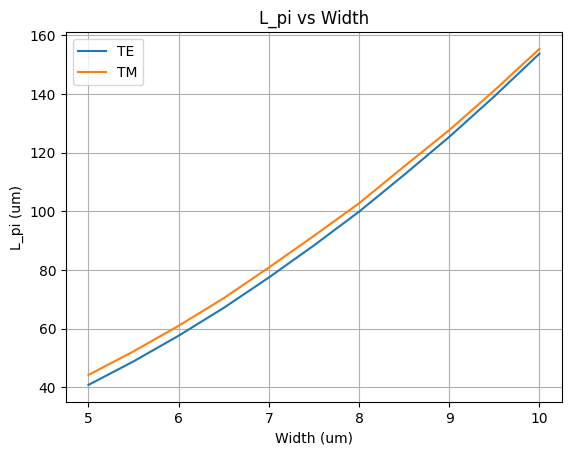

In [18]:
gap_to_simulate = 600 * nm # STUDENT. You can manually change the gap
                            # or you can sweep the parameter using a Python for loop. 
wavelength = 1.55

mmi_body_w = np.linspace(5,10,11)

Lpi_TE = []
Lpi_TM= []

TE = []
TM = []

# Para guardar el primer modo TE y TM por cada width
neff_TE_first = []
neff_TM_first = []

for w in mmi_body_w:

    mmi = gt.modes.Waveguide(
        # Geometrical Parameters
        core_width=w, # MMI Body width
        core_thickness=300 * nm, # MMI Body height 
        slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguides.
        # Materials
        core_material='sin', #  Material of the waveguide
        clad_material='sio2', # Surrounding material
        # Modesolver Parameters
        wavelength=wavelength, # Wavelength to simulate
        num_modes=15, # Targeted number of modes to find - Higher than before! It's a multimode section
        max_grid_scaling=1.5, # Parameters of the grid
        grid_resolution=20, # Parameters of the grid
        cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
        precision='double',
    )

    neff = mmi.n_eff
    TE_frac = mmi.fraction_te

    TE_modes = []
    TM_modes = []

    # Recorrer cada modo
    for idx, frac in enumerate(TE_frac):
        if frac > 0.9:
            TE_modes.append(neff[idx])
        else:
            TM_modes.append(neff[idx])

    # Guardar primer modo TE y TM
    neff_TE_first.append(TE_modes[0].real)
    neff_TM_first.append(TM_modes[0].real)

    # Calcular Lpi
    Lpi_TE.append(wavelength/(2*(TE_modes[0].real - TE_modes[1].real)))
    Lpi_TM.append(wavelength/(2*(TM_modes[0].real - TM_modes[1].real)))

# Convert to arrays
Lpi_TE = np.array(Lpi_TE)
Lpi_TM = np.array(Lpi_TM)
mmi_body_w = np.array(mmi_body_w)
neff_TE_first = np.array(neff_TE_first)
neff_TM_first = np.array(neff_TM_first)

# Plot
plt.figure()
plt.plot(mmi_body_w, Lpi_TE,label='TE')
plt.plot(mmi_body_w, Lpi_TM, label='TM')

plt.xlabel('Width (um)')
plt.ylabel('L_pi (um)')
plt.title('L_pi vs Width')
plt.legend()
plt.grid()

plt.show()

#### Shallow case

c:\Users\david\Desktop\PIC-CHERTE\DISEÑO\pic-upv-lab2\.venv\Lib\site-packages\tidy3d\components\mode\derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
c:\Users\david\Desktop\PIC-CHERTE\DISEÑO\pic-upv-lab2\.venv\Lib\site-packages\tidy3d\components\mode\derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
c:\Users\david\Desktop\PIC-CHERTE\DISEÑO\pic-upv-lab2\.ve

15:05:22 Hora estándar romance WARNING: Mode field at frequency index 0, mode   
                               index 7 does not decay at the plane boundaries.  

                               WARNING: Mode field at frequency index 0, mode   
                               index 8 does not decay at the plane boundaries.  

                               WARNING: Mode field at frequency index 0, mode   
                               index 11 does not decay at the plane boundaries. 

                               WARNING: Mode field at frequency index 0, mode   
                               index 13 does not decay at the plane boundaries. 

...

2026-03-09 15:06:28.364 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache\Waveguide_ecd907868e18d7b8.npz.


c:\Users\david\Desktop\PIC-CHERTE\DISEÑO\pic-upv-lab2\.venv\Lib\site-packages\tidy3d\components\mode\derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
c:\Users\david\Desktop\PIC-CHERTE\DISEÑO\pic-upv-lab2\.venv\Lib\site-packages\tidy3d\components\mode\derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
c:\Users\david\Desktop\PIC-CHERTE\DISEÑO\pic-upv-lab2\.ve

15:06:37 Hora estándar romance WARNING: Mode field at frequency index 0, mode   
                               index 13 does not decay at the plane boundaries. 

                               WARNING: Mode field at frequency index 0, mode   
                               index 14 does not decay at the plane boundaries. 

2026-03-09 15:06:37.885 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache\Waveguide_7e36fbbc6fa16f81.npz.


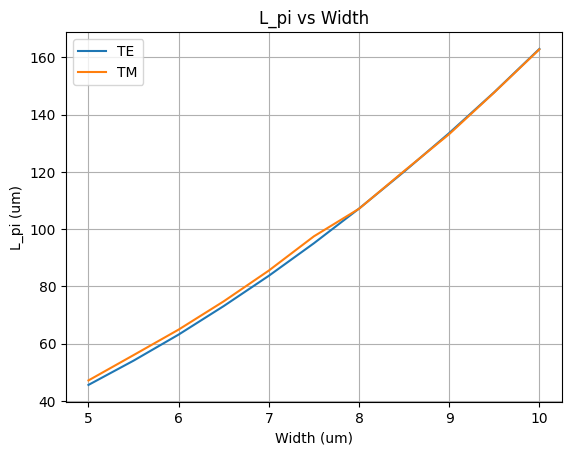

In [52]:
gap_to_simulate = 600 * nm # STUDENT. You can manually change the gap
                            # or you can sweep the parameter using a Python for loop. 
wavelength = 1.55

mmi_body_w = np.linspace(5,10,11)

Lpi_TE = []
Lpi_TM= []

TE = []
TM = []

# Para guardar el primer modo TE y TM por cada width
neff_TE_first = []
neff_TM_first = []

for w in mmi_body_w:

    mmi = gt.modes.Waveguide(
        # Geometrical Parameters
        core_width=w, # MMI Body width
        core_thickness=300 * nm, # MMI Body height 
        slab_thickness=150 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguides.
        # Materials
        core_material='sin', #  Material of the waveguide
        clad_material='sio2', # Surrounding material
        # Modesolver Parameters
        wavelength=wavelength, # Wavelength to simulate
        num_modes=15, # Targeted number of modes to find - Higher than before! It's a multimode section
        max_grid_scaling=1.5, # Parameters of the grid
        grid_resolution=30, # Parameters of the grid
        cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
        precision='double',
    )

    neff = mmi.n_eff
    TE_frac = mmi.fraction_te

    TE_modes = []
    TM_modes = []

    # Recorrer cada modo
    for idx, frac in enumerate(TE_frac):
        if frac > 0.9:
            TE_modes.append(neff[idx])
        else:
            TM_modes.append(neff[idx])

    # Guardar primer modo TE y TM
    neff_TE_first.append(TE_modes[0].real)
    neff_TM_first.append(TM_modes[0].real)

    # Calcular Lpi
    Lpi_TE.append(wavelength/(2*(TE_modes[0].real - TE_modes[1].real)))
    Lpi_TM.append(wavelength/(2*(TM_modes[0].real - TM_modes[1].real)))

# Convert to arrays
Lpi_TE = np.array(Lpi_TE)
Lpi_TM = np.array(Lpi_TM)
mmi_body_w = np.array(mmi_body_w)
neff_TE_first = np.array(neff_TE_first)
neff_TM_first = np.array(neff_TM_first)

# Plot
plt.figure()
plt.plot(mmi_body_w, Lpi_TE,label='TE')
plt.plot(mmi_body_w, Lpi_TM, label='TM')

plt.xlabel('Width (um)')
plt.ylabel('L_pi (um)')
plt.title('L_pi vs Width')
plt.legend()
plt.grid()

plt.show()